# Description

It takes a GWAS that was imputed and postprocessed (using the PrediXcan scripts here https://github.com/hakyimlab/summary-gwas-imputation) on a random phenotype and verifies that the Manhattan and QQ-plots look fine (without inflation).

# Modules

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





# Paths

In [3]:
GLS_NULL_SIMS_DIR <- Sys.getenv("PHENOPLIER_RESULTS_GLS_NULL_SIMS")

In [4]:
GLS_NULL_SIMS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims"

In [5]:
GWAS_DIR <- file.path(
    GLS_NULL_SIMS_DIR,
    "_pvalue",
    "post_imputed_gwas"
)

In [6]:
GWAS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/_pvalue/post_imputed_gwas"

In [7]:
title_prefix = "imputed"

# Random pheno 0 (beta/se)

In [ ]:
pheno_code <- "0"

## Load data

In [ ]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm-imputed.txt.gz"))))

In [ ]:
dim(gwas)

In [ ]:
head(gwas)

### Extract chromosome

In [ ]:
unique(gwas$chromosome)

In [ ]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [ ]:
unique(gwas$chrom)

## Data stats

In [ ]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [ ]:
gwas_p_stats

In [ ]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [ ]:
gwas_mlog_stats

In [ ]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [ ]:
gwas_max_mlog_noninf

In [ ]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [ ]:
gwas_zs_stats

In [ ]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [ ]:
gwas_beta_stats

In [ ]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [ ]:
gwas_se_stats

## Manhattan plot

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, gwas_max_mlog_noninf+1),
)

## QQ-plot

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)

# Random pheno 0 (pvalue)

In [8]:
pheno_code <- "0"

## Load data

In [9]:
gwas <- as.data.frame(read_table(file.path(GWAS_DIR, paste0("random.pheno", pheno_code,".glm-imputed.txt.gz"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  variant_id = col_character(),
  panel_variant_id = col_character(),
  chromosome = col_character(),
  position = col_double(),
  effect_allele = col_character(),
  non_effect_allele = col_character(),
  current_build = col_character(),
  frequency = col_double(),
  sample_size = col_double(),
  zscore = col_double(),
  pvalue = col_double(),
  effect_size = col_double(),
  standard_error = col_double(),
  imputation_status = col_character(),
  n_cases = col_logical()
)



In [10]:
dim(gwas)

[1] 8842077      15

In [11]:
head(gwas)

,variant_id,panel_variant_id,chromosome,position,effect_allele,non_effect_allele,current_build,frequency,sample_size,zscore,pvalue,effect_size,standard_error,imputation_status,n_cases
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,rs554008981,chr1_13550_G_A_b38,chr1,13550,A,G,hg38,0.01731602,10000,-0.84461477,0.3983260,NA,NA,imputed,NA
2,rs201055865,chr1_14671_G_C_b38,chr1,14671,C,G,hg38,0.01298701,10000,-0.45652345,0.6480136,NA,NA,imputed,NA
3,rs201327123,chr1_14677_G_A_b38,chr1,14677,A,G,hg38,0.05339105,10000,0.82327448,0.4103519,NA,NA,imputed,NA
4,rs199856693,chr1_14933_G_A_b38,chr1,14933,A,G,hg38,0.01154401,10000,0.80382616,0.4214974,NA,NA,imputed,NA
5,rs62636368,chr1_16841_G_T_b38,chr1,16841,T,G,hg38,0.04545455,10000,0.07630512,0.9391764,NA,NA,imputed,NA
6,rs201833382,chr1_17005_A_G_b38,chr1,17005,G,A,hg38,0.01803752,10000,-0.80721014,0.4195454,NA,NA,imputed,NA


### Extract chromosome

In [12]:
unique(gwas$chromosome)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22"

In [13]:
gwas$chrom <- gsub("chr([0-9]+)", "\\1", gwas$chromosome)
gwas <- transform(gwas, chrom = as.numeric(chrom))

In [14]:
unique(gwas$chrom)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22

## Data stats

In [15]:
gwas_p_stats <- gwas %>%
  summarise(
    mean_value = mean(pvalue, na.rm = TRUE),
    sd_value   = sd(pvalue, na.rm = TRUE),
    min_value  = min(pvalue, na.rm = TRUE),
    max_value  = max(pvalue, na.rm = TRUE),
  )

In [16]:
gwas_p_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.5024582,0.2876409,9.999936e-51,1


In [17]:
gwas_mlog_stats <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    mean_neg_log10 = mean(LOGP, na.rm = TRUE),
    sd_neg_log10   = sd(LOGP, na.rm = TRUE),
    min_neg_log10  = min(LOGP, na.rm = TRUE),
    max_neg_log10  = max(LOGP, na.rm = TRUE)
  )

In [18]:
gwas_mlog_stats

mean_neg_log10,sd_neg_log10,min_neg_log10,max_neg_log10
<dbl>,<dbl>,<dbl>,<dbl>
0.4282857,0.4248929,0,50


In [19]:
gwas_max_mlog_noninf <- gwas %>%
  mutate(LOGP = -log10(pvalue)) %>%
  summarise(
    max_no_inf = max(LOGP[is.finite(LOGP)], na.rm = TRUE)
  ) %>%
  pull(max_no_inf)

In [20]:
gwas_max_mlog_noninf

[1] 50

In [21]:
gwas_zs_stats <- gwas %>%
  summarise(
    mean_value = mean(zscore, na.rm = TRUE),
    sd_value   = sd(zscore, na.rm = TRUE),
    min_value  = min(zscore, na.rm = TRUE),
    max_value  = max(zscore, na.rm = TRUE),
  )

In [22]:
gwas_zs_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-0.001185662,0.9895109,-4.90427,14.97948


In [23]:
gwas_beta_stats <- gwas %>%
  summarise(
    mean_value = mean(effect_size, na.rm = TRUE),
    sd_value   = sd(effect_size, na.rm = TRUE),
    min_value  = min(effect_size, na.rm = TRUE),
    max_value  = max(effect_size, na.rm = TRUE),
  )

In [24]:
gwas_beta_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
-2.828224e-05,0.03344061,-0.369534,0.322691


In [25]:
gwas_se_stats <- gwas %>%
  summarise(
    mean_value = mean(standard_error, na.rm = TRUE),
    sd_value   = sd(standard_error, na.rm = TRUE),
    min_value  = min(standard_error, na.rm = TRUE),
    max_value  = max(standard_error, na.rm = TRUE),
  )

In [26]:
gwas_se_stats

mean_value,sd_value,min_value,max_value
<dbl>,<dbl>,<dbl>,<dbl>
0.02956737,0.01580844,0.0136786,0.236104


## Manhattan plot

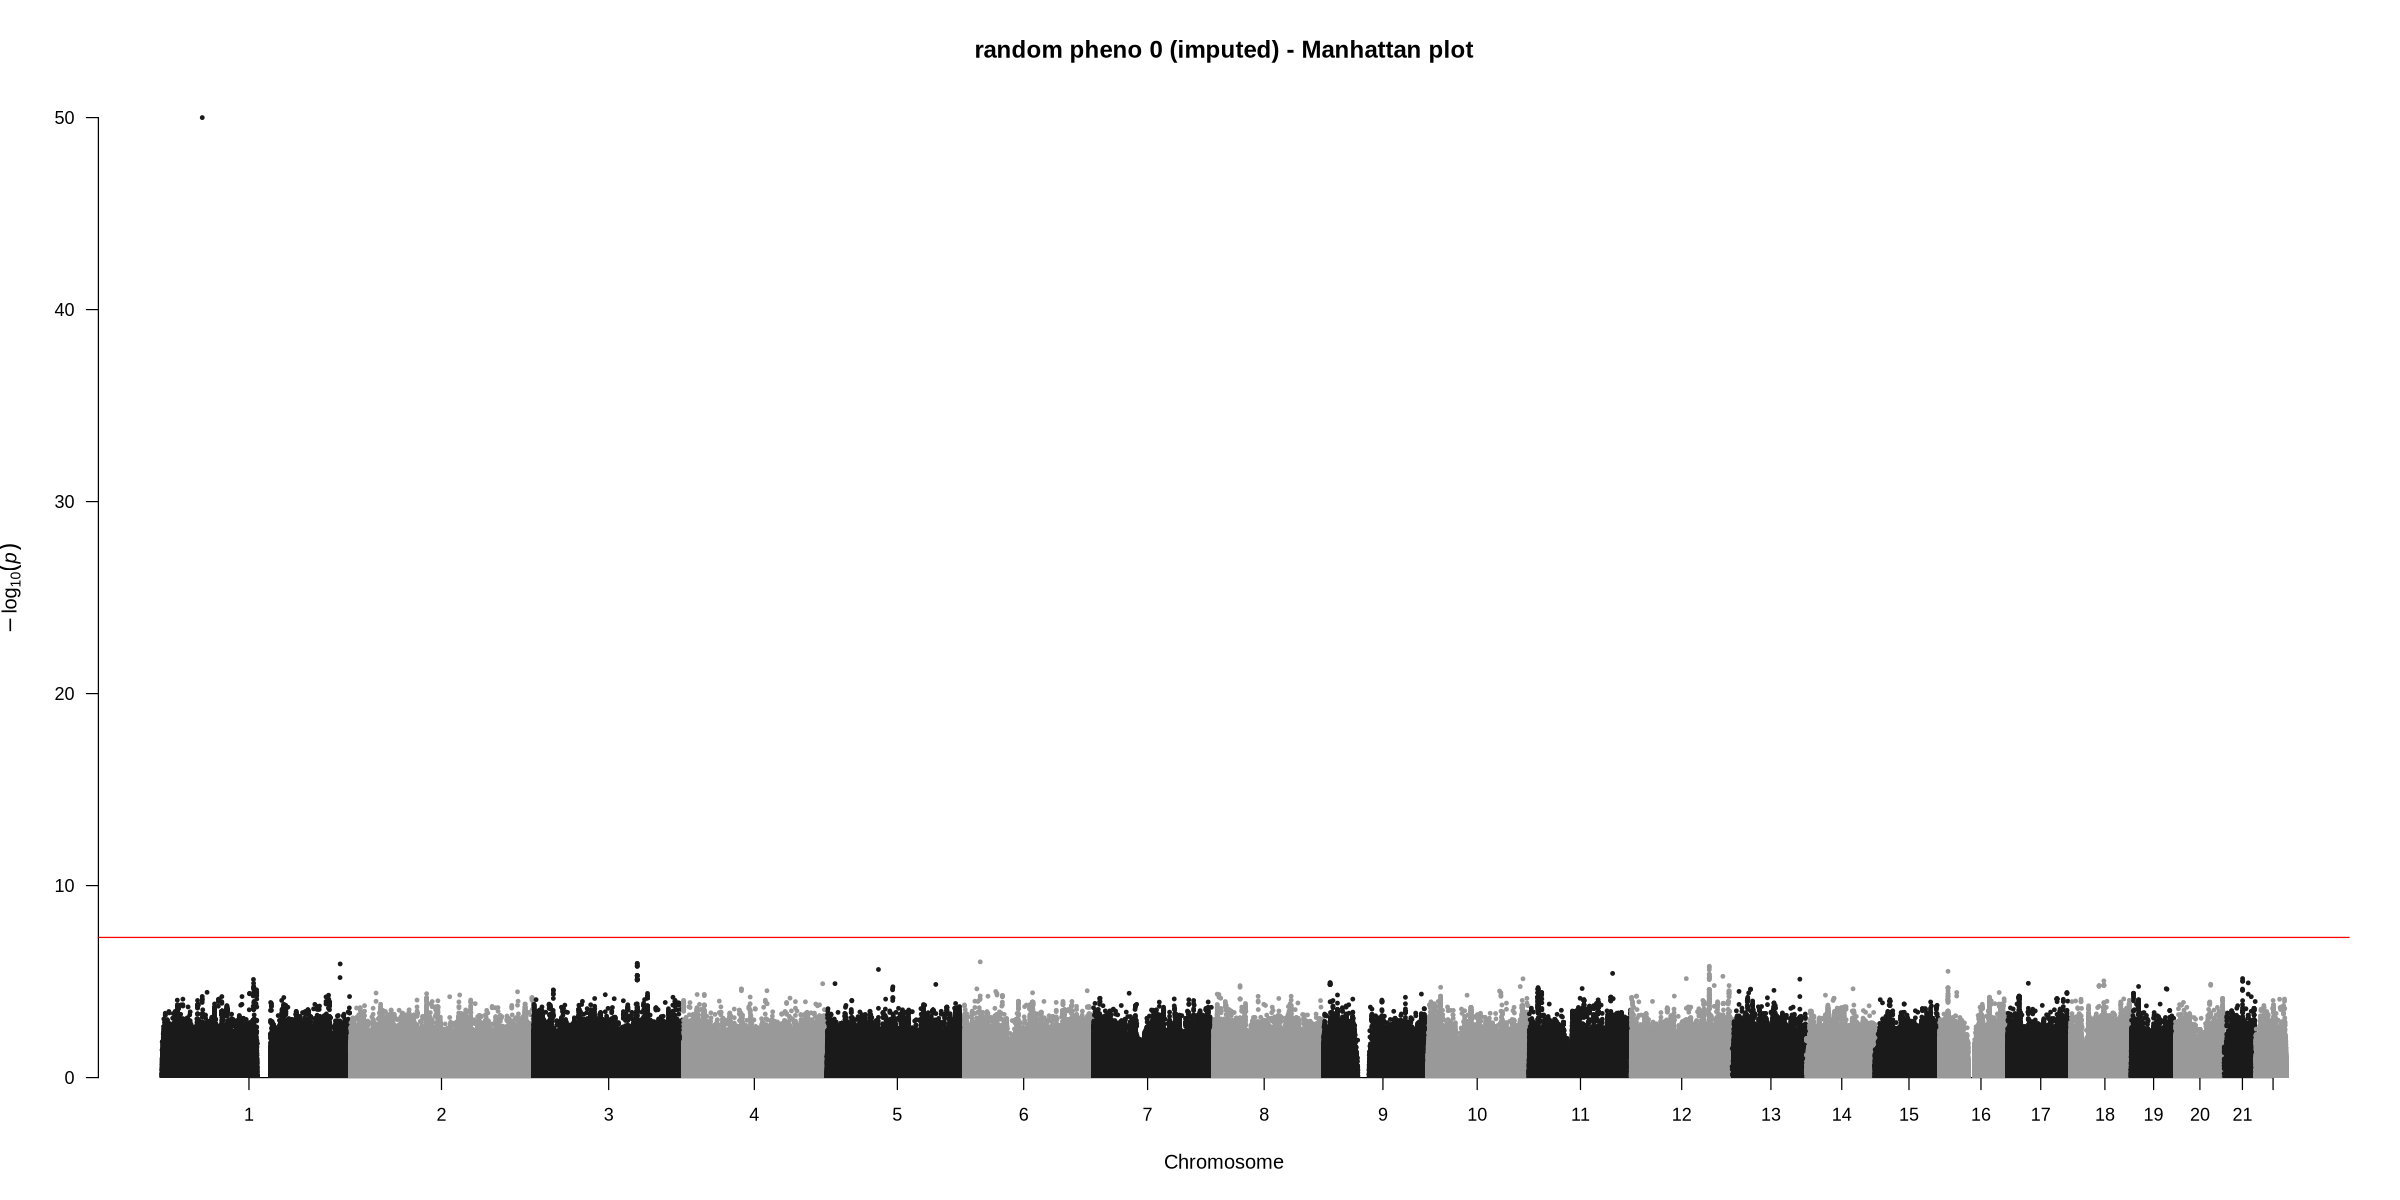

In [27]:
options(repr.plot.width = 20, repr.plot.height = 10)

manhattan(
  gwas,
  chr = "chrom",
  bp = "position",
  p = "pvalue",
  snp = "variant_id",
  main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - Manhattan plot"),
  suggestiveline = F,
  genomewideline = -log10(5e-08),
  cex = 0.6,
  cex.axis = 0.9,
  ylim = c(0, gwas_max_mlog_noninf+1),
)

## QQ-plot

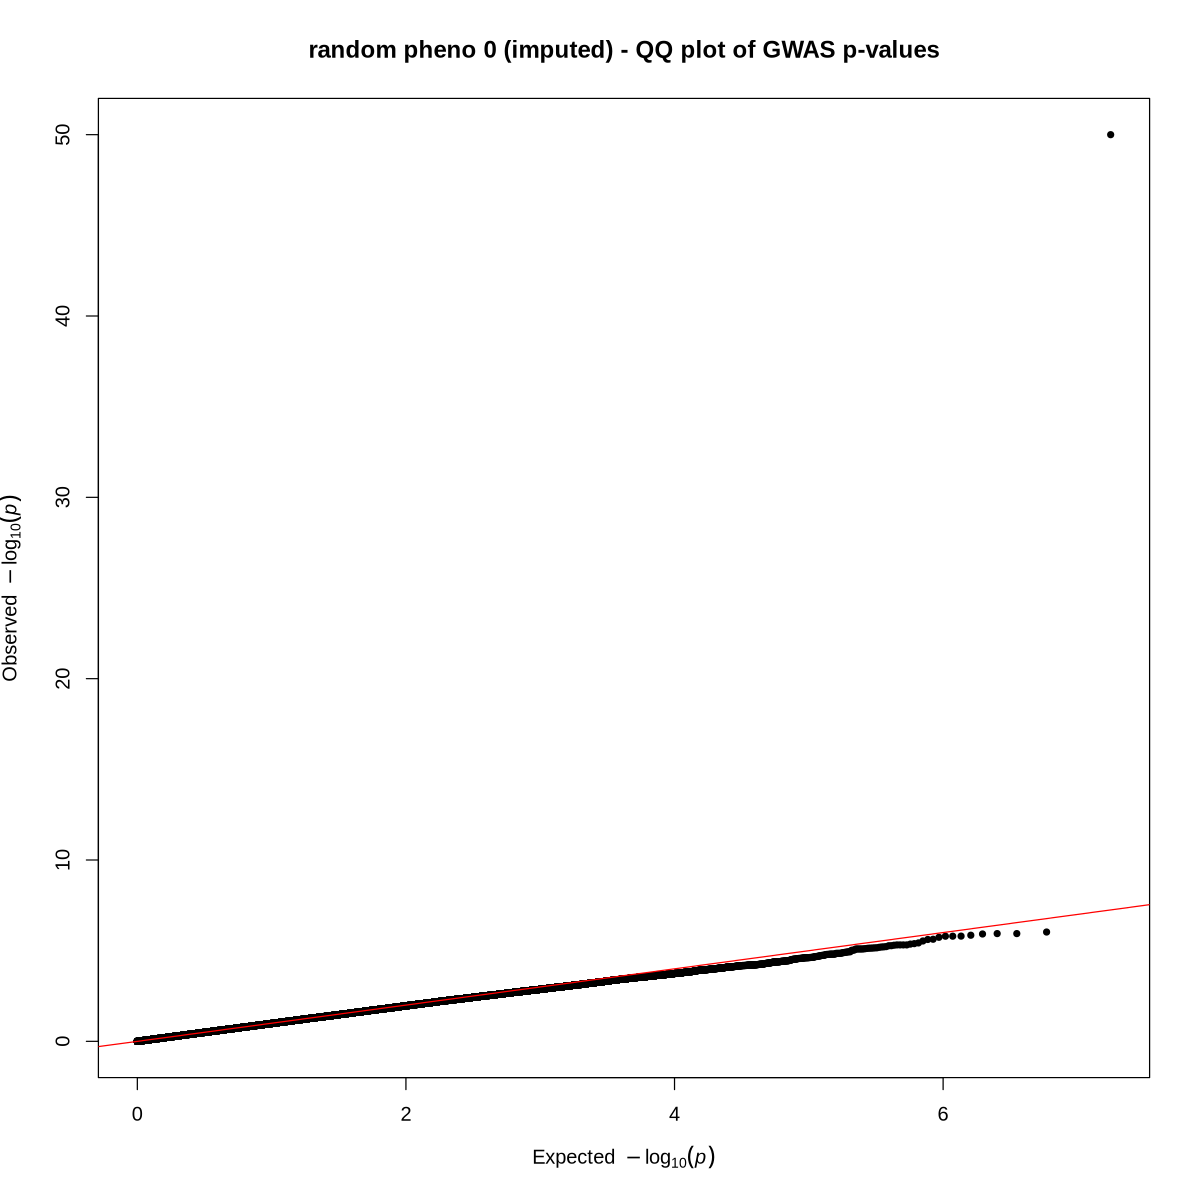

In [28]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    gwas$pvalue,
    main = paste0("random pheno ", pheno_code, " (", title_prefix, ")", " - QQ plot of GWAS p-values")
)